<a href="https://colab.research.google.com/github/ojos168/HW2_Stress_Prediction/blob/main/Stress_Prediction_EDA_and_Baseline_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Loading and Setup

In this section, I load the required Python libraries for data manipulation and visualization. I also load the raw dataset from a CSV file. The dataset used is the Human Stress Prediction Dataset, containing Reddit posts labeled as 1 (stress) or 0 (no stress).

In [7]:
# import necessary libraries for data science and text processing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import CountVectorizer

# set the visual style for academic charts
sns.set_theme(style="whitegrid", palette="pastel")

# load the dataset
url = 'https://raw.githubusercontent.com/ojos168/HW2_Stress_Prediction/refs/heads/main/Stress.csv'
df = pd.read_csv(url)

# display basic information about the dataset
print("Dataset Shape (Rows, Columns):", df.shape)
display(df.head())

Dataset Shape (Rows, Columns): (2838, 7)


,subreddit,post_id,sentence_range,text,label,confidence,social_timestamp
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",1,0.8,1521614353
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",0,1.0,1527009817
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,1,0.8,1535935605
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",1,0.6,1516429555
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1,0.8,1539809005


##Data Cleaning and Feature Engineering

The text need to be clean before analyzed. I remove duplicates, missing values, URLs, and punctuation to reduce noise. Furthermore, I engineer two new features to help answer my research question:
- word_count: The total number of words in a post.
- first_person_count: The frequency of first-person pronouns (I, me, my), which psycholinguistic theory suggests is an indicator of psychological distress.

In [8]:
# step 1: drop missing values and duplicates to ensure data quality
df = df.dropna(subset=['text', 'label'])
df = df.drop_duplicates(subset=['text'])

# step 2: define a function to clean the raw Reddit text
def clean_text(text):
  text = str(text).lower() # Convert to lowercase
  text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Remove URLs
  text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
  return text

# apply the cleaning function to create a new column
df['cleaned_text'] = df['text'].apply(clean_text)

# step 3: Feature Engineering - calculate Word Count
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

# step 4: feature engineering - count first-person pronouns
# i use regex to find standalone words: i, me, my, mine, myself
def count_first_person(text):
  pronouns = re.findall(r'\b(i|me|my|mine|myself)\b', text)
  return len(pronouns)

df['first_person_count'] = df['cleaned_text'].apply(count_first_person)

print(f"Data cleaning finished. Remaining rows: {df.shape[0]}")
display(df[['cleaned_text', 'label', 'word_count', 'first_person_count']].head())

Data cleaning finished. Remaining rows: 2820


,cleaned_text,label,word_count,first_person_count
0,he said he had not felt that way before sugget...,1,113,10
1,hey there rassistance not sure if this is the ...,0,107,1
2,my mom then hit me with the newspaper and it s...,1,166,15
3,until i met my new boyfriend he is amazing he ...,1,273,43
4,october is domestic violence awareness month a...,1,89,7


##Exploratory Data Analysis (EDA)

In this section, I create four visualizations to understand the distributions within my dataset and explore preliminary relationships between language use and stress labels.

/tmp/ipykernel_1581/590125794.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', ax=axes[0, 0], palette=['#64b5f6', '#e57373'])
/tmp/ipykernel_1581/590125794.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['No Stress (0)', 'Stress (1)'])
/tmp/ipykernel_1581/590125794.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='word_count', ax=axes[0, 1], palette=['#64b5f6', '#e57373'])
/tmp/ipykernel_1581/590125794.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixe

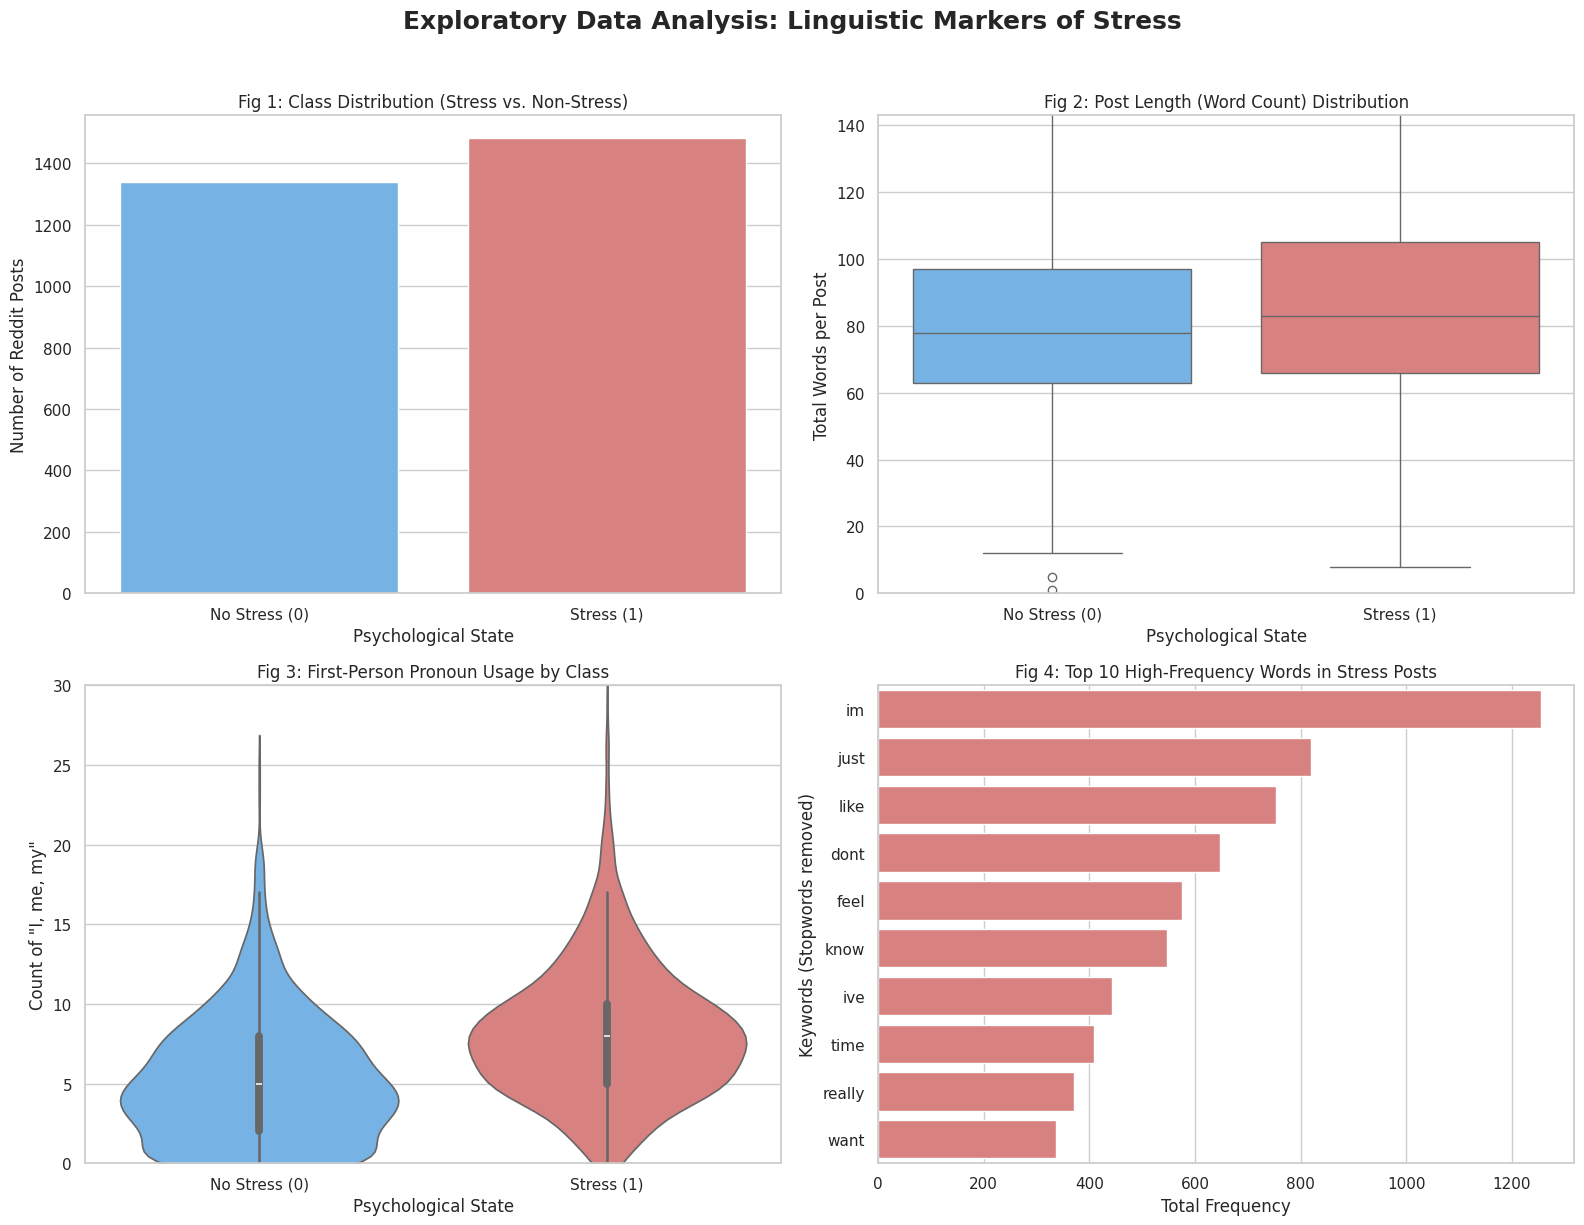

In [9]:
# create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis: Linguistic Markers of Stress', fontsize=18, fontweight='bold', y=1.02)

# visualization 1: distribution of labels (target variable)
# connection to RQ: ensures the dataset is balanced for training my NLP model.
sns.countplot(data=df, x='label', ax=axes[0, 0], palette=['#64b5f6', '#e57373'])
axes[0, 0].set_title('Fig 1: Class Distribution (Stress vs. Non-Stress)')
axes[0, 0].set_xticklabels(['No Stress (0)', 'Stress (1)'])
axes[0, 0].set_xlabel('Psychological State')
axes[0, 0].set_ylabel('Number of Reddit Posts')

# visualization 2: Word Count by Class
# connection to RQ: checks if stressed users write longer posts (a potential behavioral marker).
sns.boxplot(data=df, x='label', y='word_count', ax=axes[0, 1], palette=['#64b5f6', '#e57373'])
axes[0, 1].set_title('Fig 2: Post Length (Word Count) Distribution')
axes[0, 1].set_xticklabels(['No Stress (0)', 'Stress (1)'])
axes[0, 1].set_xlabel('Psychological State')
axes[0, 1].set_ylabel('Total Words per Post')
# limit y-axis to remove extreme outliers and make the boxplot readable
axes[0, 1].set_ylim(0, df['word_count'].quantile(0.95))

# visualization 3: first-person pronoun frequency
# connection to RQ: directly tests a psycholinguistic marker (LIWC) before complex ML modeling.
sns.violinplot(data=df, x='label', y='first_person_count', ax=axes[1, 0], palette=['#64b5f6', '#e57373'])
axes[1, 0].set_title('Fig 3: First-Person Pronoun Usage by Class')
axes[1, 0].set_xticklabels(['No Stress (0)', 'Stress (1)'])
axes[1, 0].set_xlabel('Psychological State')
axes[1, 0].set_ylabel('Count of "I, me, my"')
axes[1, 0].set_ylim(0, 30)

# visualization 4: Top 10 Most Frequent Words in Stress Posts
# connection to RQ: shows the semantic content of stress posts to guide my future SHAP explanation analysis.
stress_texts = df[df['label'] == 1]['cleaned_text']
# I use CountVectorizer to count words, ignoring standard english stop words
vectorizer = CountVectorizer(stop_words='english', max_features=10)
word_matrix = vectorizer.fit_transform(stress_texts)
word_freq = pd.DataFrame(word_matrix.sum(axis=0), columns=vectorizer.get_feature_names_out()).T
word_freq.columns = ['Frequency']
word_freq = word_freq.sort_values(by='Frequency', ascending=False)

sns.barplot(x=word_freq['Frequency'], y=word_freq.index, ax=axes[1, 1], color='#e57373')
axes[1, 1].set_title('Fig 4: Top 10 High-Frequency Words in Stress Posts')
axes[1, 1].set_xlabel('Total Frequency')
axes[1, 1].set_ylabel('Keywords (Stopwords removed)')

plt.tight_layout()
plt.show()